In [2]:

from ifc.config import TRAIN_FILE, TEST_FILE, TARGET, CLASSES, ID_COLS, CATEGORICAL_COLS, NUMERICAL_COLS, DROP_COLS, SEED

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(SEED)

train_df = pd.read_csv(TRAIN_FILE)
test_df  = pd.read_csv(TEST_FILE)
train_df.drop(DROP_COLS,axis=1, inplace=True)

print(train_df.shape)
print(test_df.shape)

(11828, 28)
(5811, 27)


### 1. Dataset Structure
- Column types and non-null counts
- Temporal split sanity check (train 2018–2021, test 2022–2023)
- Unique companies and rows per company

In [16]:
train_df.head()

,company_id,fiscal_year,province,region,ateco_sector,legal_form,years_in_business,total_fixed_assets,current_assets,total_assets,shareholders_equity,total_debt,short_term_debt,long_term_debt,production_value,production_costs,operating_income,financial_income,financial_expenses,net_profit_loss,roe,roi,leverage,current_ratio,quick_ratio,debt_to_assets,profit_margin,financial_health_class
0,COMP_00000,2018,NaN,Campania,47,SRL,32,2.422343e+08,9.504819e+08,1.192716e+09,3.728702e+08,8.198459e+08,5.601842e+08,2.596617e+08,1.846636e+09,1.611363e+09,2.352729e+08,4886785.12,20068071.29,2.152049e+08,0.5772,0.1973,2.1987,1.6967,1.0180,0.6874,0.1165,B
1,COMP_00000,2019,NaN,Campania,47,SRL,33,3.983639e+07,1.411226e+08,1.809589e+08,5.700701e+07,1.239519e+08,7.135345e+07,5.259848e+07,4.289159e+08,3.896038e+08,3.931218e+07,58246.06,2537224.20,3.677495e+07,0.6451,0.2172,2.1743,1.9778,1.1867,0.6850,0.0857,B
2,COMP_00000,2020,NaN,Campania,47,SRL,34,6.662250e+08,1.367208e+09,2.033433e+09,3.029046e+08,1.730529e+09,9.904004e+08,7.401282e+08,6.956197e+09,6.988489e+09,-3.229208e+07,5327332.51,55844558.38,-8.813664e+07,-0.2910,-0.0159,5.7131,1.3805,0.8283,0.8510,-0.0127,D
3,COMP_00000,2021,NaN,Campania,47,SRL,35,4.637187e+07,2.524228e+08,2.987947e+08,3.901098e+07,2.597837e+08,1.527674e+08,1.070163e+08,5.031839e+08,5.047235e+08,-1.539645e+06,116335.80,7828741.61,-9.368387e+06,-0.2401,-0.0052,6.6592,1.6523,0.9914,0.8694,-0.0186,D
4,COMP_00001,2018,CA,Sardegna,62,SRL,8,8.348035e+07,1.325697e+08,2.160500e+08,6.566937e+07,1.503807e+08,7.582482e+07,7.455584e+07,4.113380e+08,3.912414e+08,2.009667e+07,640538.94,5860639.22,1.423603e+07,0.2168,0.0930,2.2900,1.7484,1.0490,0.6960,0.0346,B


In [ ]:

train_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 11828 entries, 0 to 11827
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   company_id              11828 non-null  str    
 1   fiscal_year             11828 non-null  int64  
 2   province                10909 non-null  str    
 3   region                  11828 non-null  str    
 4   ateco_sector            11828 non-null  int64  
 5   legal_form              11828 non-null  str    
 6   years_in_business       11828 non-null  int64  
 7   total_fixed_assets      11828 non-null  float64
 8   current_assets          11828 non-null  float64
 9   total_assets            11828 non-null  float64
 10  shareholders_equity     11828 non-null  float64
 11  total_debt              11828 non-null  float64
 12  short_term_debt         11828 non-null  float64
 13  long_term_debt          11828 non-null  float64
 14  production_value        11828 non-null  float64
 

In [ ]:

print("Train years:", sorted(train_df["fiscal_year"].unique()))
print("Test years: ", sorted(test_df["fiscal_year"].unique()))


Train years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
Test years:  [np.int64(2022), np.int64(2023)]


In [ ]:

print("Unique companies — train:", train_df["company_id"].nunique())
print("Unique companies — test: ", test_df["company_id"].nunique())

rows_per_company = train_df.groupby("company_id").size().value_counts().sort_index()
print("\nRows per company:\n", rows_per_company)


Unique companies — train: 2999
Unique companies — test:  2916

Rows per company:
 1      20
2      24
3      60
4    2895
Name: count, dtype: int64


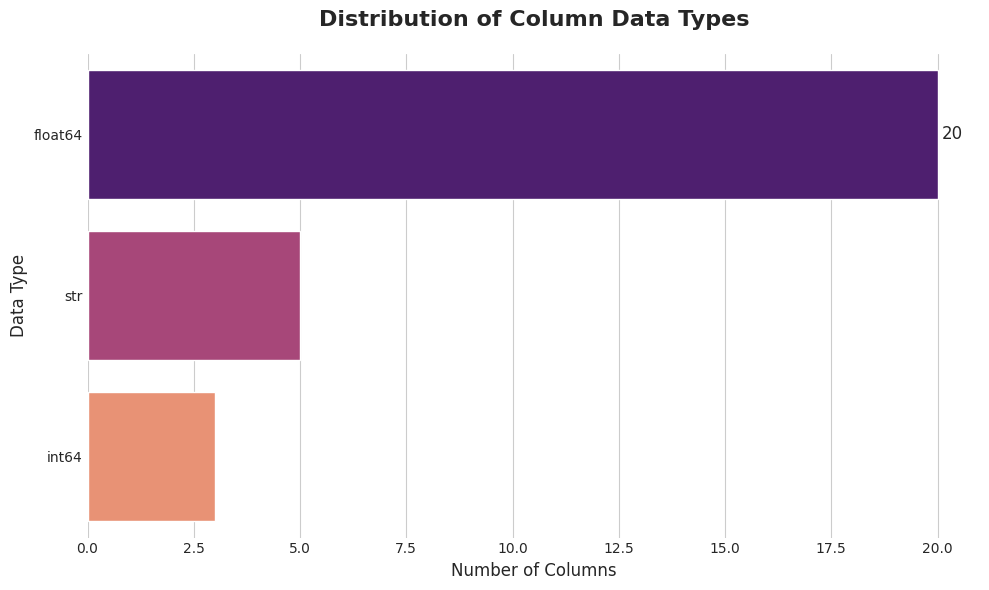

In [12]:

data_types = train_df.dtypes.value_counts().reset_index()
data_types.columns = ['Dtype', 'Count']

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=data_types, 
    x='Count', 
    y='Dtype', 
    palette='magma',
    hue='Dtype',
    legend=False
)

ax.bar_label(ax.containers[0], padding=3, fontsize=12)

plt.title('Distribution of Column Data Types', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Number of Columns', fontsize=12)
plt.ylabel('Data Type', fontsize=12)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [17]:

full_years = set([2018, 2019, 2020, 2021])

company_years = train_df.groupby("company_id")["fiscal_year"].apply(set)
incomplete = company_years[company_years.apply(len) < 4]

print(f"Companies with incomplete history: {len(incomplete)} / {train_df['company_id'].nunique()}")

summary = pd.DataFrame({
    "years_present": incomplete,
    "years_missing": incomplete.apply(lambda y: sorted(full_years - y)),
    "n_years": incomplete.apply(len)
})

print("\nMissing year patterns:")
print(summary["years_missing"].value_counts())


Companies with incomplete history: 104 / 2999

Missing year patterns:
years_missing
[2018]                37
[2021]                23
[2020, 2021]          23
[2019, 2020, 2021]    20
[2018, 2021]           1
Name: count, dtype: int64


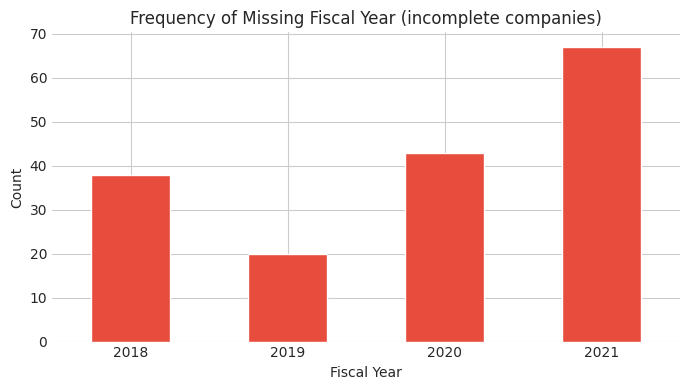

In [18]:
# Visualise: which fiscal year is most often absent
from itertools import chain

all_missing = list(chain.from_iterable(summary["years_missing"]))
missing_counts = pd.Series(all_missing).value_counts().sort_index()

missing_counts.plot(kind="bar", color="#e74c3c", edgecolor="white", figsize=(7, 4))
plt.title("Frequency of Missing Fiscal Year (incomplete companies)")
plt.xlabel("Fiscal Year"); plt.ylabel("Count")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


In [19]:
# Are incomplete companies concentrated in a specific class or sector?
incomplete_ids = incomplete.index
incomplete_df = train_df[train_df["company_id"].isin(incomplete_ids)]

print("Class distribution — incomplete companies:")
print(incomplete_df.drop_duplicates("company_id")[TARGET].value_counts(normalize=True).round(3))

print("\nTop sectors — incomplete companies:")
print(incomplete_df.drop_duplicates("company_id")["ateco_sector"].value_counts().head(10))


Class distribution — incomplete companies:
financial_health_class
B    0.433
D    0.288
C    0.221
A    0.058
Name: proportion, dtype: float64

Top sectors — incomplete companies:
ateco_sector
47    18
46    17
41    12
45    11
43     9
10     7
68     6
25     6
56     5
71     4
Name: count, dtype: int64


In [20]:
# Check for year gaps within a company's history (e.g. 2018, 2020 — missing 2019)
def find_gaps(years):
    years = sorted(years)
    gaps = []
    for i in range(len(years) - 1):
        expected = years[i] + 1
        actual = years[i + 1]
        if actual != expected:
            gaps.append((years[i], actual))  # (last seen, next seen)
    return gaps

company_gaps = company_years.apply(find_gaps)
companies_with_gaps = company_gaps[company_gaps.apply(len) > 0]

print(f"Companies with year gaps: {len(companies_with_gaps)} / {train_df['company_id'].nunique()}")
print("\nGap patterns (from_year → to_year):")
print(companies_with_gaps.explode().value_counts())


Companies with year gaps: 0 / 2999

Gap patterns (from_year → to_year):
Series([], Name: count, dtype: int64)


In [22]:
# For each incomplete company, check if missing years are at the start or end
def missing_position(years):
    years = sorted(years)
    missing = sorted(full_years - set(years))
    positions = []
    for y in missing:
        if y < years[0]:
            positions.append("start")   # missing early years → entered dataset late
        elif y > years[-1]:
            positions.append("end")     # missing late years → exited dataset early
        else:
            positions.append("middle")  # impossible given no gaps, but safety check
    return positions

summary["missing_position"] = summary["years_present"].apply(missing_position)
print(summary["missing_position"].explode().value_counts())


missing_position
end      130
start     38
Name: count, dtype: int64


In [24]:
# Do companies missing 2021 skew toward D?
missing_2021 = summary[summary["years_missing"].apply(lambda x: 2021 in x)].index
print("Class dist — missing 2021 (early exits):")
print(train_df[train_df["company_id"].isin(missing_2021)][TARGET].value_counts(normalize=True).round(3))

# Compare to full dataset
print("\nClass dist — full dataset:")
print(train_df[TARGET].value_counts(normalize=True).round(3))


Class dist — missing 2021 (early exits):
financial_health_class
D    0.650
C    0.190
B    0.131
A    0.029
Name: proportion, dtype: float64

Class dist — full dataset:
financial_health_class
B    0.593
C    0.232
D    0.089
A    0.085
Name: proportion, dtype: float64



- Scalers and imputers must be **fit on train only**, then applied to test
- Lag features must use **only past data** (year `t-1` → year `t`)
- Never use features from year `t+1` to predict class at year `t`

---

### 🔍 Finding: Incomplete Companies are Not Missing at Random

**104 companies have fewer than 4 years** in the training set:

| Pattern | Count | Interpretation |
|---|---|---|
| Missing at **end** (early exits) | 130 observations | Company stopped filing — likely distress |
| Missing at **start** (late entrants) | 38 observations | Young company, entered after 2018 |

**Early exits are strongly associated with class D:**

| Class | Early Exits | Full Dataset |
|-------|-------------|--------------|
| A     | 2.9%        | 8.5%         |
| B     | 13.1%       | 59.3%        |
| C     | 19.0%       | 23.2%        |
| D     | **65.0%**   | **8.9%**     |

65% of companies that disappeared before 2021 were class D — vs only 8.9% in the full dataset.  
This is **informative missingness**, not random. These companies stopped filing due to severe financial distress.

> **Survivorship bias**: companies present in the test set (2022–2023) are survivors by definition.  
> The model may underestimate D risk for companies that will exit mid-period. This is a known limitation.

---

### Time Dimension as an Asset: Lag Features

Since most companies have 4 consecutive years of contiguous data, we can engineer **trend features**  
that capture whether a company's financial health is improving or deteriorating.

A company with ROE dropping from `0.4 → 0.1` is riskier than one stable at `0.15`,  
even though the current value is higher. Raw snapshots miss this signal.

**Features to engineer (computed at year `t` using year `t-1`)**:

| Feature | Formula | Signal |
|---|---|---|
| `roe_prev` | `roe` at `t-1` | Profitability baseline |
| `roi_prev` | `roi` at `t-1` | Efficiency baseline |
| `current_ratio_prev` | `current_ratio` at `t-1` | Liquidity baseline |
| `roe_yoy` | `roe_t - roe_{t-1}` | Profitability trend |
| `roi_yoy` | `roi_t - roi_{t-1}` | Efficiency trend |
| `leverage_trend` | `leverage_t - leverage_{t-1}` | Increasing debt signal |
| `equity_growth` | `(equity_t - equity_{t-1}) / abs(equity_{t-1})` | Capital erosion signal |
| `is_last_observation` | 1 if final row for company | Exit/distress signal |
| `n_years_in_panel` | count of years in dataset | Short history = higher risk |

> Late entrants (38 companies missing 2018) will have `NaN` lag features on their first row → imputed with median during preprocessing.  
> `is_last_observation` and `n_years_in_panel` must be computed **before** the train/test split to avoid leakage.

---

### Cross-Validation Strategy

Standard k-fold CV is **not valid** here because it would leak future data into training.  
Use **time-based expanding window CV** on the training set:

| Fold | Train | Validation |
|---|---|---|
| 1 | 2018 | 2019 |
| 2 | 2018–2019 | 2020 |
| 3 | 2018–2020 | 2021 ← most important |

Use `sklearn.model_selection.TimeSeriesSplit` or build manually on `fiscal_year`.  
**Never shuffle** when splitting.

---

### Full Modeling Flow
Sort by company_id + fiscal_year

Compute panel features: is_last_observation, n_years_in_panel

Engineer lag features (shift within each company group)

Temporal train/val split for CV (no shuffle)

Fit scaler + imputer on train only → transform val and test

Train classifier on all train years (2018–2021)

Predict on test set (2022–2023)

Evaluate: Weighted F1 (primary), Confusion Matrix, Per-class Precision/Recall

## 2. Target Variable Analysis
- Class counts and percentages (A/B/C/D)
- Class distribution per `fiscal_year` — detect COVID drift in 2020–2021
- Class distribution by `ateco_sector`, `legal_form`, `region`

In [ ]:

counts = train_df[TARGET].value_counts().reindex(CLASSES)
pcts   = train_df[TARGET].value_counts(normalize=True).reindex(CLASSES) * 100

print(pd.concat([counts, pcts.round(2)], axis=1, keys=["count", "%"]))


                        count      %
financial_health_class              
A                        1003   8.48
B                        7017  59.33
C                        2750  23.25
D                        1058   8.94


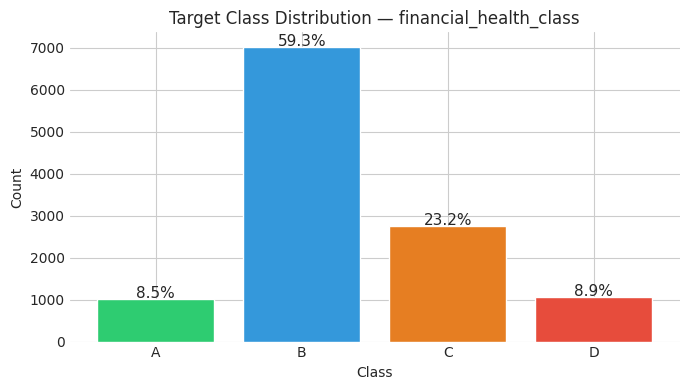

In [26]:

fig, ax = plt.subplots(figsize=(7, 4))
palette = {"A": "#2ecc71", "B": "#3498db", "C": "#e67e22", "D": "#e74c3c"}
bars = ax.bar(CLASSES, counts, color=[palette[c] for c in CLASSES], edgecolor="white")
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{pct:.1f}%", ha="center", fontsize=11)
ax.set_title("Target Class Distribution — financial_health_class")
ax.set_xlabel("Class"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()


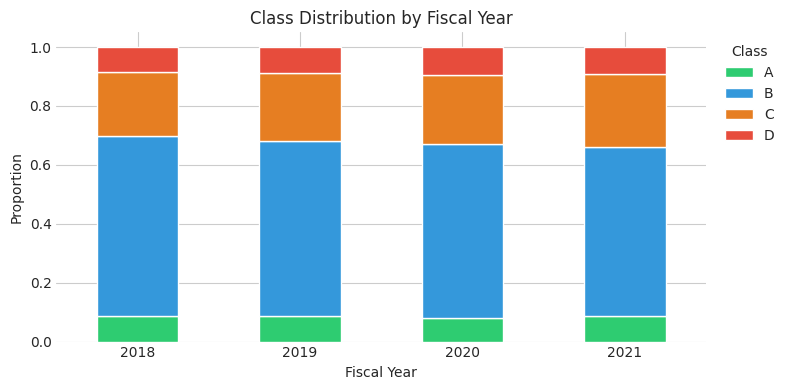

financial_health_class    A     B    C    D
fiscal_year                                
2018                    254  1815  640  252
2019                    260  1766  691  262
2020                    239  1745  695  277
2021                    250  1691  724  267


In [27]:
# 2.3 Class distribution per fiscal year — detect COVID drift
yearly = pd.crosstab(train_df["fiscal_year"], train_df[TARGET], normalize="index")[CLASSES]

yearly.plot(kind="bar", stacked=True, figsize=(8, 4),
            color=[palette[c] for c in CLASSES], edgecolor="white")
plt.title("Class Distribution by Fiscal Year")
plt.ylabel("Proportion"); plt.xlabel("Fiscal Year")
plt.xticks(rotation=0); plt.legend(title="Class", bbox_to_anchor=(1.01, 1))
plt.tight_layout(); plt.show()

# Raw numbers per year
print(pd.crosstab(train_df["fiscal_year"], train_df[TARGET]))


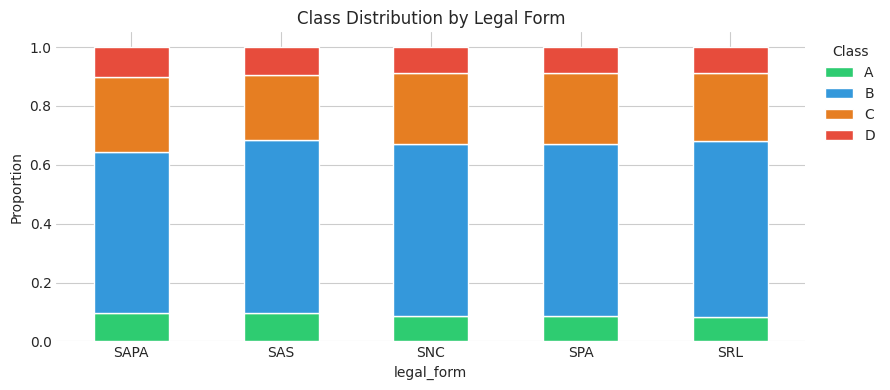

financial_health_class,A,B,C,D
legal_form,,,,
SAPA,0.094972,0.547486,0.256983,0.100559
SAS,0.096452,0.586475,0.220621,0.096452
SNC,0.087948,0.583062,0.241042,0.087948
SPA,0.086624,0.584713,0.239490,0.089172
SRL,0.082798,0.597221,0.231344,0.088637


In [36]:

legal = pd.crosstab(train_df["legal_form"], train_df[TARGET], normalize="index")[CLASSES]
legal.plot(kind="bar", stacked=True, figsize=(9, 4),
           color=[palette[c] for c in CLASSES], edgecolor="white")
plt.title("Class Distribution by Legal Form")
plt.ylabel("Proportion"); plt.xticks(rotation=0)
plt.legend(title="Class", bbox_to_anchor=(1.01, 1))
plt.tight_layout(); plt.show()

legal

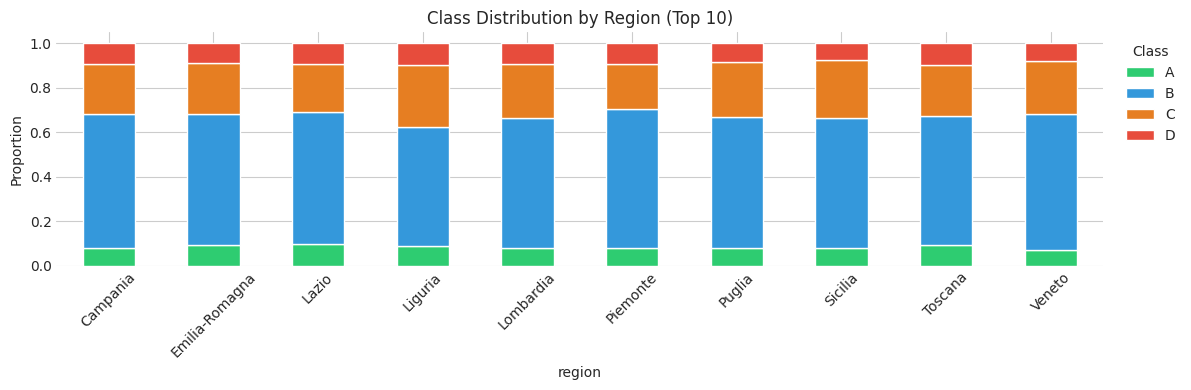

financial_health_class,A,B,C,D
region,,,,
Campania,0.078346,0.606094,0.224157,0.091404
Emilia-Romagna,0.093593,0.588913,0.228942,0.088553
Lazio,0.096123,0.597451,0.214551,0.091875
Liguria,0.087282,0.538653,0.276808,0.097257
Lombardia,0.078696,0.586645,0.241653,0.093005
Piemonte,0.080402,0.623116,0.202261,0.094221
Puglia,0.077406,0.592050,0.246862,0.083682
Sicilia,0.079065,0.584633,0.260579,0.075724
Toscana,0.092926,0.581137,0.227462,0.098474


In [35]:
# 2.5 Class distribution by region (top 10 regions by count)
top_regions = train_df["region"].value_counts().head(10).index
region_df = train_df[train_df["region"].isin(top_regions)]

region = pd.crosstab(region_df["region"], region_df[TARGET], normalize="index")[CLASSES]
region.plot(kind="bar", stacked=True, figsize=(12, 4),
            color=[palette[c] for c in CLASSES], edgecolor="white")
plt.title("Class Distribution by Region (Top 10)")
plt.ylabel("Proportion"); plt.xticks(rotation=45)
plt.legend(title="Class", bbox_to_anchor=(1.01, 1))
plt.tight_layout(); plt.show()

region

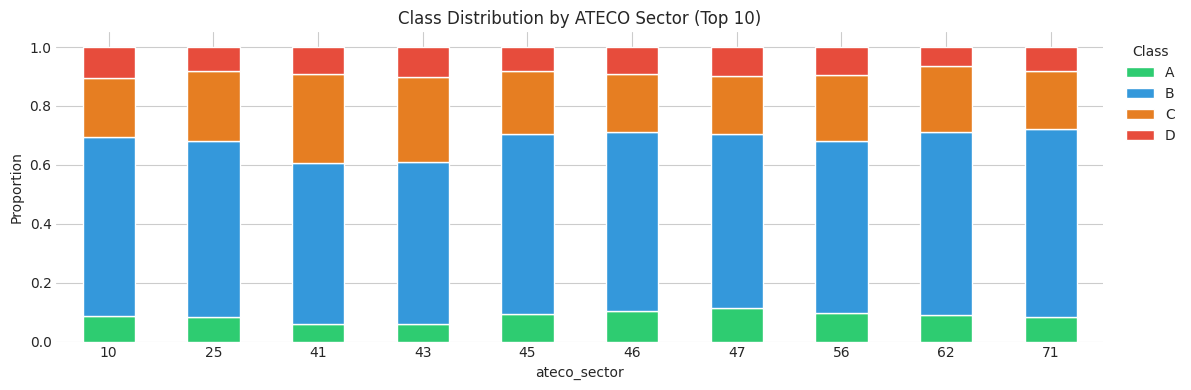

financial_health_class,A,B,C,D
ateco_sector,,,,
10,0.085595,0.608559,0.200418,0.105428
25,0.084932,0.597260,0.236530,0.081279
41,0.059386,0.548123,0.300341,0.092150
43,0.061396,0.549201,0.287637,0.101766
45,0.095166,0.610272,0.212991,0.081571
46,0.102488,0.608412,0.196682,0.092417
47,0.114017,0.590879,0.196512,0.098592
56,0.098143,0.582228,0.225464,0.094164
62,0.091579,0.620000,0.224211,0.064211


In [34]:
# 2.6 Class distribution by ateco_sector (top 10 sectors by count)
top_sectors = train_df["ateco_sector"].value_counts().head(10).index
sector_df = train_df[train_df["ateco_sector"].isin(top_sectors)]

sector = pd.crosstab(sector_df["ateco_sector"], sector_df[TARGET], normalize="index")[CLASSES]
sector.plot(kind="bar", stacked=True, figsize=(12, 4),
            color=[palette[c] for c in CLASSES], edgecolor="white")
plt.title("Class Distribution by ATECO Sector (Top 10)")
plt.ylabel("Proportion"); plt.xticks(rotation=0)
plt.legend(title="Class", bbox_to_anchor=(1.01, 1))
plt.tight_layout(); plt.show()

sector

## Section 2 — Target Variable Analysis: Findings

### 2.1 Class Imbalance

The dataset is **moderately imbalanced**:

| Class | Count | % |
|-------|-------|---|
| A — Excellent | 1,003 | 8.5% |
| B — Good | 7,017 | 59.3% |
| C — Moderate risk | 2,750 | 23.3% |
| D — High risk | 1,058 | 8.9% |

B dominates the dataset. A and D are the minority classes and the hardest to classify correctly.
This means **accuracy is a misleading metric** — a model predicting B for everything would reach 59% accuracy.
→ Use **Weighted F1** as primary metric. Apply `class_weight="balanced"` in all models.

---

### 2.2 No COVID Drift Detected

Class distribution is **remarkably stable** across all 4 years:

| Year | A | B | C | D |
|------|---|---|---|---|
| 2018 | 254 | 1815 | 640 | 252 |
| 2019 | 260 | 1766 | 691 | 262 |
| 2020 | 239 | 1745 | 695 | 277 |
| 2021 | 250 | 1691 | 724 | 267 |

No significant spike in D during 2020–2021 despite COVID-19.
C shows a mild upward trend (+13% from 2018 to 2021) but no structural shift.
→ `fiscal_year` is **not a strong standalone predictor** — but keep it as a feature
to capture any subtle macro trend the model can learn.

---

### 2.3 Legal Form has Minimal Predictive Power

All legal forms (SRL, SPA, SAS, SNC, SAPA) show nearly identical class distributions,
all within ±2% of the global baseline.
→ `legal_form` is a **weak feature**. Encode it but don't expect high importance.

---

### 2.4 Region has Minimal Predictive Power

Regional differences are small. Notable exceptions:
- **Liguria** has the highest C rate (27.7%) and lowest B rate (53.9%) — slightly riskier
- **Piemonte** has the highest B rate (62.3%) — slightly healthier
- **Veneto** has the lowest A rate (7.0%)

Differences are marginal (~5% range across regions).
→ `region` is a **weak feature**. Consider grouping into macro-areas (Nord/Centro/Sud)
to reduce cardinality without losing the small signal.

---

### 2.5 ATECO Sector has Moderate Predictive Power

More meaningful variation than region or legal form:
- **Construction (41, 43)** — highest C rates (30%, 28.8%) and lowest A rates (~6%) →
  capital-intensive sectors with thin margins and high debt
- **Wholesale trade (46, 47)** — highest A rates (10.2%, 11.4%) → healthier cash flow
  businesses
- **IT services (62)** — lowest D rate (6.4%) → knowledge-based sectors are more resilient
- **Food manufacturing (10)** — highest D rate (10.5%)

→ `ateco_sector` is a **meaningful feature**. Keep at full granularity.
Also engineer **sector-relative ratios** (e.g., `roe - sector_median_roe`) to
capture how a company performs vs its peers.

---

### Preprocessing Decisions from Section 2

1. **Never use accuracy** — always Weighted F1
2. **Apply `class_weight="balanced"`** in all classifiers
3. **Keep `fiscal_year`** as a feature (mild macro signal)
4. **Encode `legal_form` and `region`** but expect low importance
5. **Keep `ateco_sector` at full granularity** — engineer sector-relative ratio features
6. **Consider macro-region grouping** (Nord/Centro/Sud) as an additional feature
